# GAM Diagnostics with `gratia` and `mgcv`

## Overview

GAM diagnostics answer four core questions:

1. **Are the residuals well-behaved?** — `appraise()` / `gam.check()`
2. **Is the basis dimension k large enough?** — `k.check()` / `gam.check()`
3. **Are predictors concurve (the GAM analog of multicollinearity)?** — `concurvity()`
4. **Does the model fit the data well overall?** — deviance explained, AIC, DHARMa

For non-Gaussian GAMs (binomial, Poisson, NB, Tweedie, Gamma), standard residual plots are not interpretable — use DHARMa simulation-based residuals instead (see `03_mixed_effects_models/dharma_diagnostics.ipynb` for full DHARMa coverage).

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(mgcv)
library(gratia)    # ggplot2-based GAM diagnostics
library(DHARMa)    # simulation-based residuals for non-Gaussian GAMs

set.seed(42)
n <- 300

# ── Reference models used throughout ─────────────────────────────────────────
# Gaussian GAM
gauss_data <- tibble(
  x1  = runif(n, 0, 10),
  x2  = runif(n, 0, 5),
  y   = sin(x1) * 4 + 0.5 * x2^1.5 + rnorm(n, 0, 1.5)
)
gam_gauss <- mgcv::gam(y ~ s(x1) + s(x2), data = gauss_data, method = "REML")

# NB GAM
nb_data <- tibble(
  pH    = runif(n, 6, 9),
  depth = runif(n, 0, 30),
  mu    = exp(2 + 0.8 * sin(pH - 6) - 0.03 * depth),
  count = MASS::rnegbin(n, mu = mu, theta = 2)
) %>% select(-mu)
gam_nb <- mgcv::gam(count ~ s(pH) + s(depth), data = nb_data,
                     family = mgcv::nb(), method = "REML")

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'mgcv' was built under R version 4.4.3"
Loading required package: nlme


Attaching package: 'nlme'


The fo

---

## 1. Residual Diagnostics: `gratia::appraise()`

`appraise()` is `gratia`'s ggplot2-based equivalent of `mgcv::gam.check()`. It produces four diagnostic panels for Gaussian GAMs.

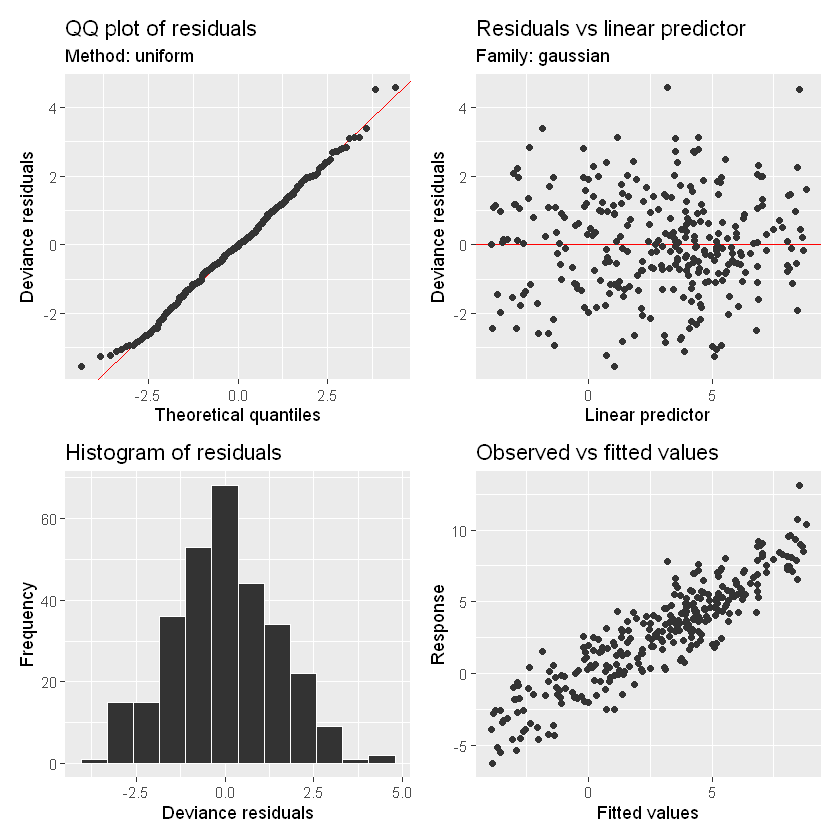


Method: REML   Optimizer: outer newton
full convergence after 11 iterations.
Gradient range [-2.044779e-05,7.475682e-08]
(score 564.9853 & scale 2.220247).
Hessian positive definite, eigenvalue range [0.459221,148.5973].
Model rank =  19 / 19 

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

        k'  edf k-index p-value
s(x1) 9.00 8.34    1.09    0.93
s(x2) 9.00 2.58    0.93    0.10


Registered S3 methods overwritten by 'mgcViz':
  method       from   
  +.gg         ggplot2
  simulate.gam gratia 



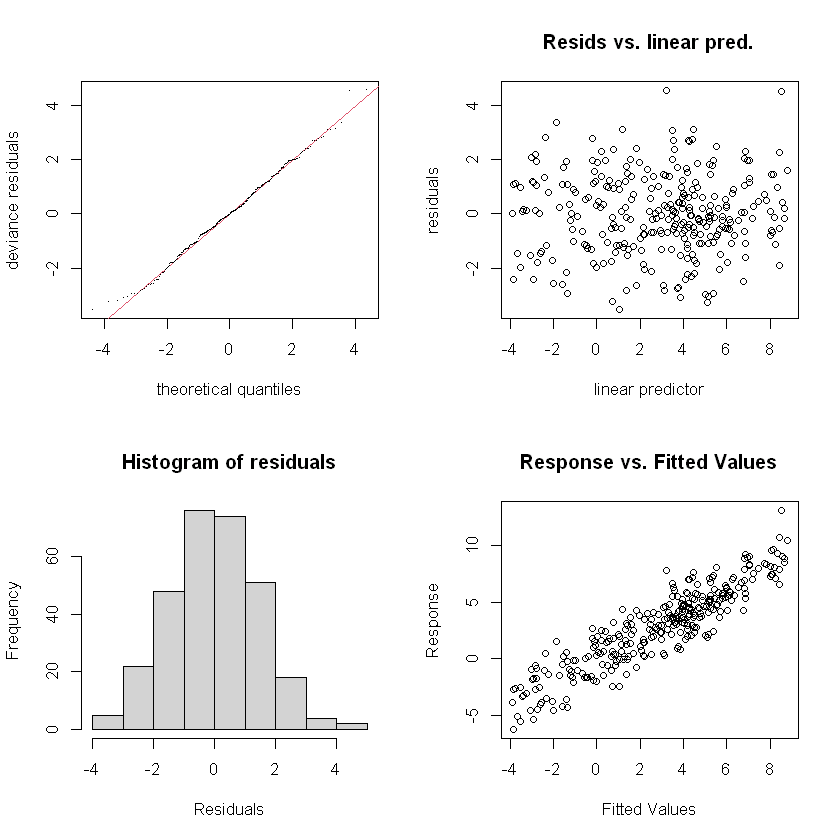

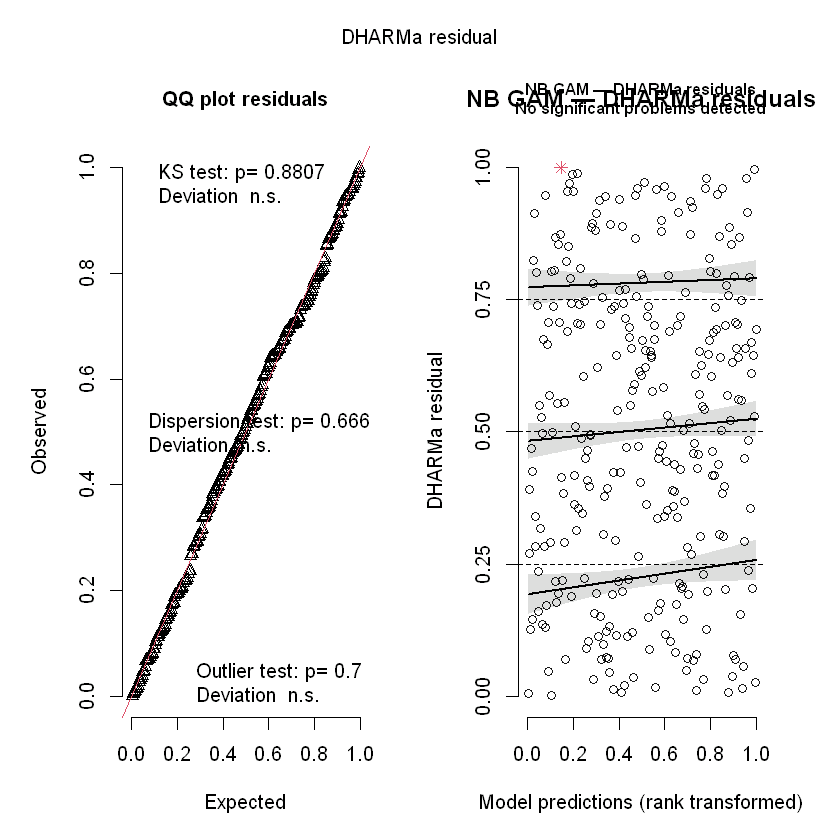


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 0.93158, p-value = 0.666
alternative hypothesis: two.sided


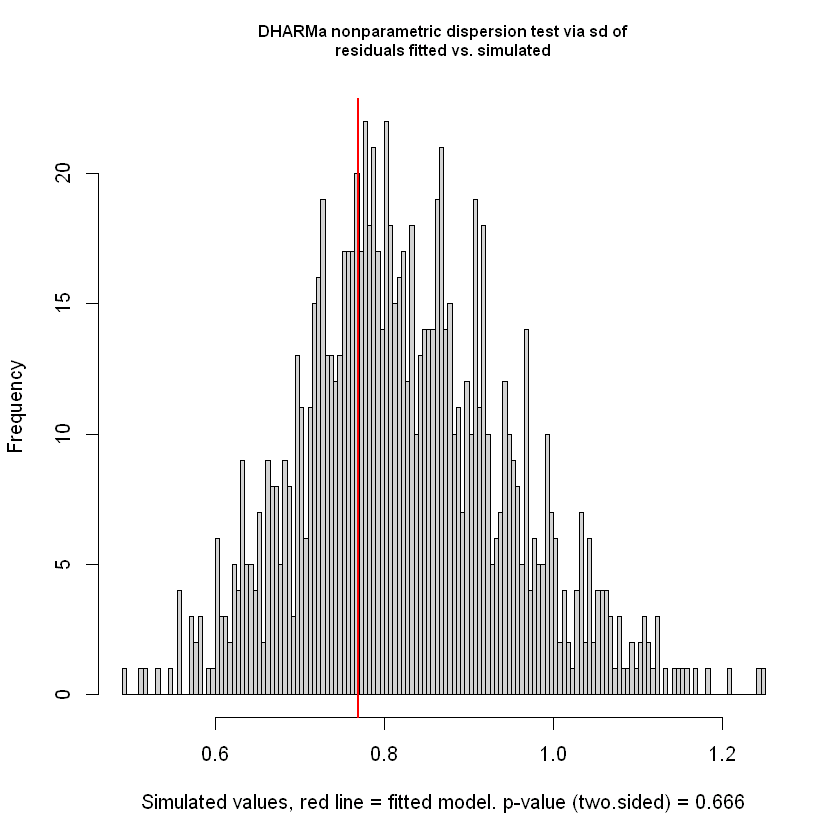


	DHARMa zero-inflation test via comparison to expected zeros with
	simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 0.93363, p-value = 0.986
alternative hypothesis: two.sided


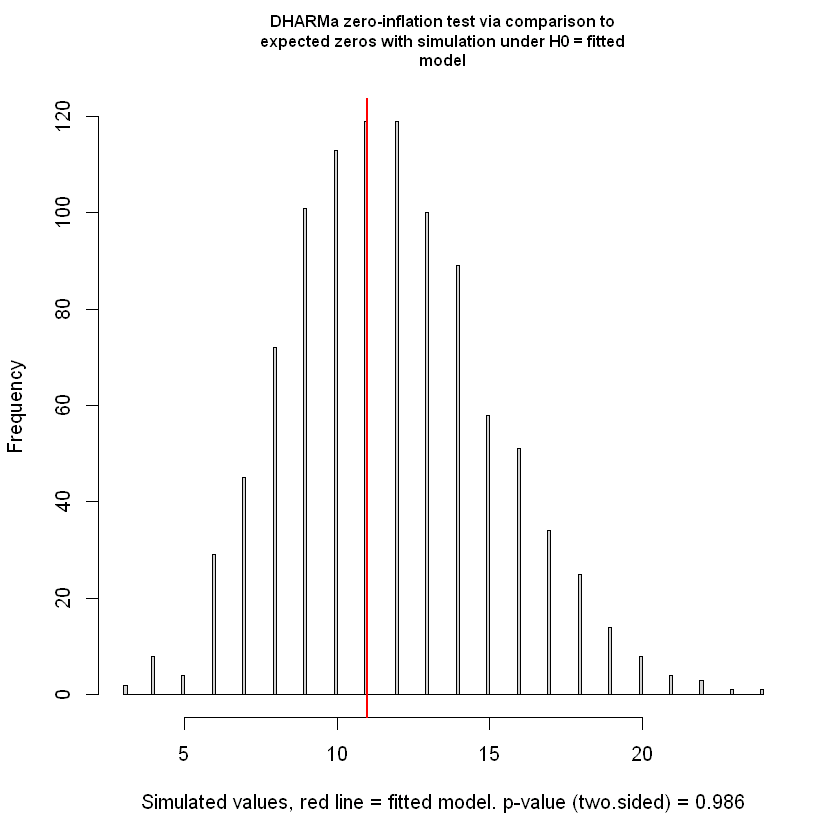

In [2]:
# ── gratia::appraise() — four panels ─────────────────────────────────────────
gratia::appraise(gam_gauss)
# Panel 1: QQ plot of deviance residuals — points on diagonal = normality
# Panel 2: Residuals vs. linear predictor — random scatter = homoscedasticity
# Panel 3: Histogram of residuals — should be approximately normal
# Panel 4: Response vs. fitted values — points on diagonal = good fit

# ── Base R equivalent: mgcv::gam.check() ─────────────────────────────────────
mgcv::gam.check(gam_gauss)
# Also prints k-index values (see section 2 below)

# ── For non-Gaussian GAMs: use DHARMa ────────────────────────────────────────
# appraise() / gam.check() residuals are not reliable for NB, binomial, etc.
sim_nb <- DHARMa::simulateResiduals(gam_nb, n = 1000)
plot(sim_nb, main = "NB GAM — DHARMa residuals")
DHARMa::testDispersion(sim_nb)
DHARMa::testZeroInflation(sim_nb)

### Residuals vs. Each Predictor

Check each predictor individually for residual patterns that suggest misspecification.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


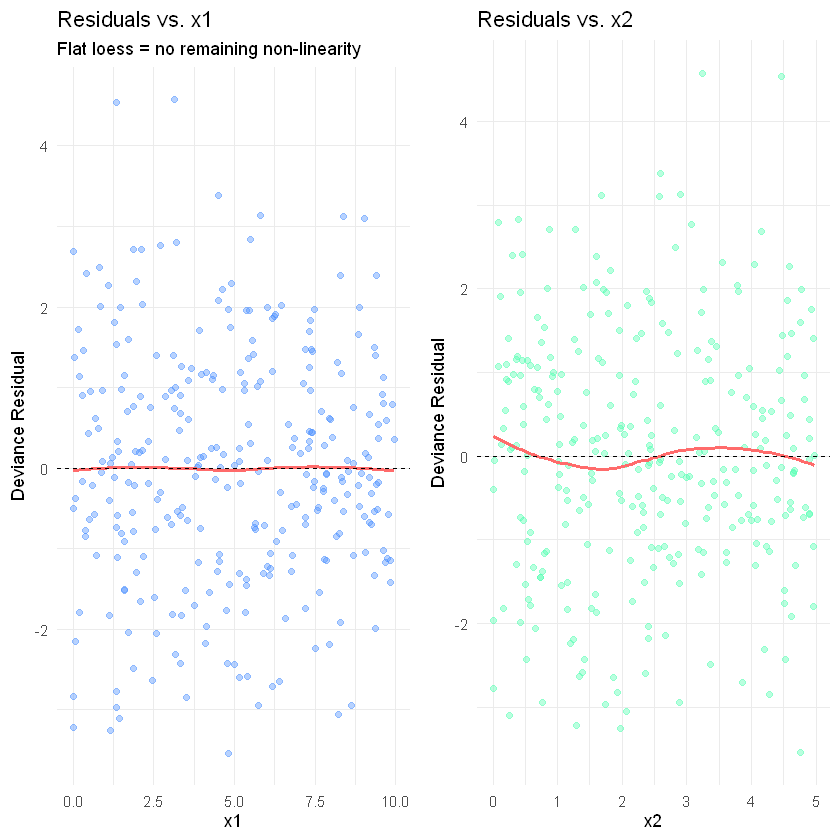

In [3]:
# ── gratia: residuals vs. each predictor ─────────────────────────────────────
resid_df <- gauss_data %>%
  mutate(
    fitted   = fitted(gam_gauss),
    residual = residuals(gam_gauss, type = "deviance")
  )

p1 <- ggplot(resid_df, aes(x = x1, y = residual)) +
  geom_point(alpha = 0.4, color = "#4a8fff") +
  geom_smooth(method = "loess", se = FALSE, color = "#ff6b6b") +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(title = "Residuals vs. x1",
       subtitle = "Flat loess = no remaining non-linearity",
       x = "x1", y = "Deviance Residual") +
  theme_minimal()

p2 <- ggplot(resid_df, aes(x = x2, y = residual)) +
  geom_point(alpha = 0.4, color = "#4fffb0") +
  geom_smooth(method = "loess", se = FALSE, color = "#ff6b6b") +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(title = "Residuals vs. x2", x = "x2", y = "Deviance Residual") +
  theme_minimal()

gridExtra::grid.arrange(p1, p2, ncol = 2)
# Curved loess line → residual non-linearity → consider increasing k or adding a term
# For DHARMa: use DHARMa::plotResiduals(sim_nb, form = nb_data$pH)

---

## 2. Basis Dimension Check: `k.check()`

The `k` argument sets the maximum basis dimension for each smooth. If k is too small, the smooth is artificially constrained and cannot capture the true relationship. Always check.

In [6]:
# ── k.check() from mgcv ───────────────────────────────────────────────────────
mgcv::k.check(gam_gauss)
# Columns:
#   k': effective k (k - 1 for most bases)
#   edf: estimated degrees of freedom
#   k-index: ratio of residual variation at scale k to overall
#            values < 1 with low p-value = k is likely too small
#   p-value: significance of the k-index test

# ── Interpretation guide ──────────────────────────────────────────────────────
# k-index >= 1, p > 0.05: k is adequate, no need to increase
# k-index < 1, p < 0.05: k may be too small — increase k and recheck
# EDF close to k-1: smooth is being artificially constrained — increase k

# ── Demonstrate: too-small k ─────────────────────────────────────────────────
gam_small_k <- mgcv::gam(y ~ s(x1, k = 3) + s(x2, k = 3),
                           data = gauss_data, method = "REML")
mgcv::k.check(gam_small_k)
# Should show k-index < 1 and significant p — k is constraining the fit

# ── Fix: increase k and recheck ───────────────────────────────────────────────
gam_larger_k <- mgcv::gam(y ~ s(x1, k = 20) + s(x2, k = 20),
                            data = gauss_data, method = "REML")
mgcv::k.check(gam_larger_k)
# EDF now well below k-1: k is no longer constraining the smooth

# Rule of thumb: k should be large enough that EDF < k - 1 comfortably
# Increasing k beyond what the data support just slows fitting — it does
# not overfit because the smoothing penalty controls wiggliness

# ── gratia k check ───────────────────────────────────────────────────────────
# NOTE: gratia does not currently export a k-check function.
# Use mgcv::k.check() above for all k diagnostics.

,k',edf,k-index,p-value
s(x1),9,8.344526,1.0872106,0.9375
s(x2),9,2.579001,0.9300291,0.1075


,k',edf,k-index,p-value
s(x1),2,1.982681,0.3143249,0.0000
s(x2),2,1.000369,1.0726011,0.8725


,k',edf,k-index,p-value
s(x1),19,11.258645,1.1089899,0.9725
s(x2),19,2.588642,0.9305689,0.1100


---

## 3. Concurvity

Concurvity is the GAM analog of multicollinearity. It occurs when one smooth term in the model can be approximated by a combination of other smooth terms. High concurvity inflates the uncertainty of smooth estimates and makes individual effects difficult to interpret.

| Concurvity Value | Interpretation |
|---|---|
| < 0.5 | Low — estimates are reliable |
| 0.5–0.8 | Moderate — investigate; consider whether predictors can be simplified |
| > 0.8 | High — smooth estimates are unreliable; interpret with caution |

,para,s(x1),s(x2)
worst,1.657836e-25,0.09383305,0.09383305
observed,1.657836e-25,0.04229796,0.01940587
estimate,1.657836e-25,0.03726110,0.02405734


,para,s(x1),s(x2)
para,1.000000e+00,6.372083e-27,1.556107e-25
s(x1),6.850047e-27,1.000000e+00,9.383305e-02
s(x2),1.567044e-25,9.383305e-02,1.000000e+00
,para,s(x1),s(x2)
para,1.000000e+00,4.229452e-29,2.092592e-33
s(x1),6.850047e-27,1.000000e+00,1.940587e-02
s(x2),1.567044e-25,4.229796e-02,1.000000e+00
,para,s(x1),s(x2)
para,1.000000e+00,1.151825e-29,3.912924e-28
s(x1),6.850047e-27,1.000000e+00,2.405734e-02


,para,s(x1),s(x2)
worst,3.62667e-25,0.9777323,0.9777323
observed,3.62667e-25,0.7891146,0.9719990
estimate,3.62667e-25,0.9545287,0.9513256


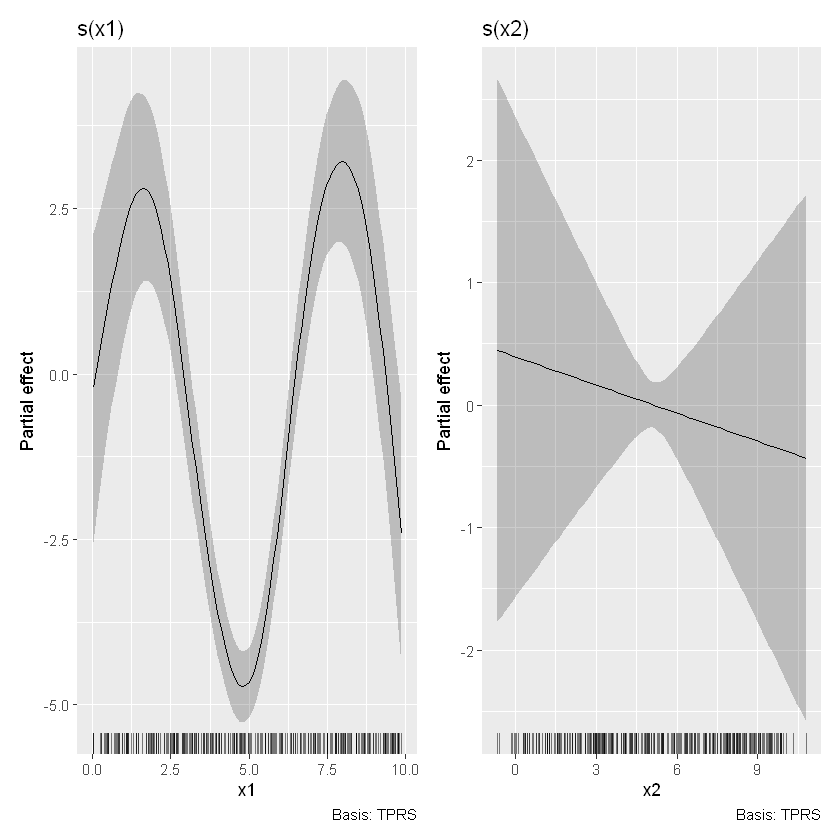

In [7]:
# ── Check concurvity ─────────────────────────────────────────────────────────
mgcv::concurvity(gam_gauss, full = TRUE)
# full = TRUE: worst case, observed, and estimate concurvity for each term
# 'worst': maximum possible concurvity — conservative upper bound
# 'observed': concurvity based on actual data — most relevant
# 'estimate': smoothed estimate

mgcv::concurvity(gam_gauss, full = FALSE)
# full = FALSE: pairwise concurvity between all pairs of smooth terms

# ── Demonstrate high concurvity ───────────────────────────────────────────────
# Create correlated predictors
conc_data <- tibble(
  x1  = runif(n, 0, 10),
  x2  = x1 + rnorm(n, 0, 0.5),   # x2 is nearly identical to x1
  y   = sin(x1) * 4 + rnorm(n, 0, 1.5)
)
gam_conc <- mgcv::gam(y ~ s(x1) + s(x2), data = conc_data, method = "REML")
mgcv::concurvity(gam_conc, full = TRUE)
# Observed concurvity near 1 — smooth estimates are very uncertain

# ── Visualize the problem ─────────────────────────────────────────────────────
# Wide CIs on smooths when concurvity is high
gratia::draw(gam_conc)
# Compare: gratia::draw(gam_gauss) — much tighter CIs

---

## 4. Overall Model Fit

Assess how well the model fits the data using deviance explained, AIC, and visual comparison of observed vs. fitted values.

R-sq (adj) = 0.817
Deviance explained = 82.3%
AIC = 1106.3
n = 300, EDF total = 10.9


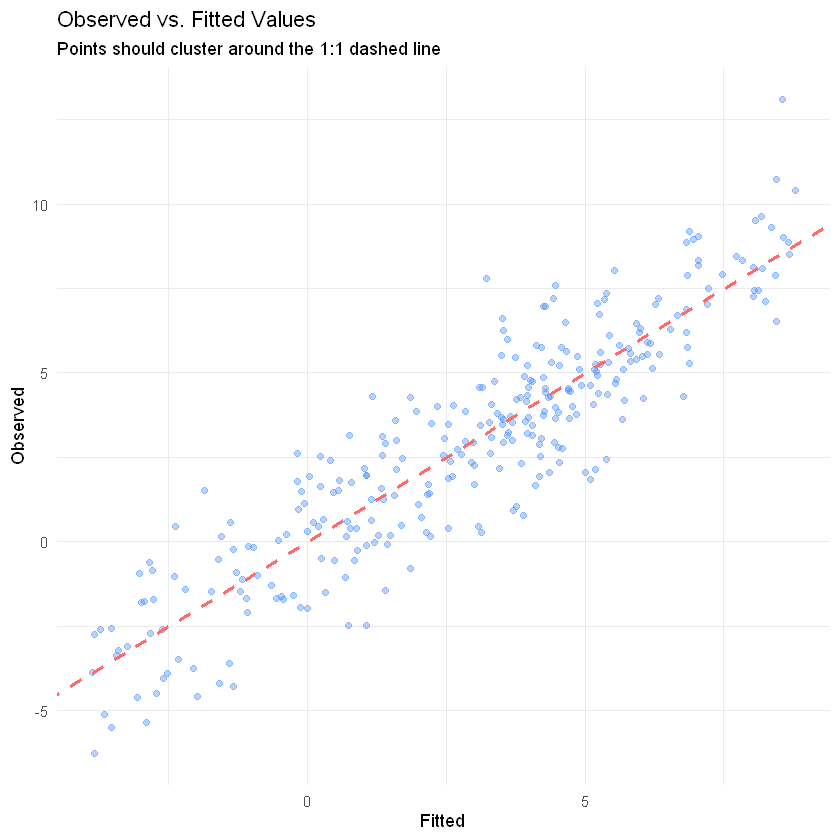

In [8]:
# ── Summary statistics ────────────────────────────────────────────────────────
s <- summary(gam_gauss)
cat(sprintf("R-sq (adj) = %.3f\n", s$r.sq))
cat(sprintf("Deviance explained = %.1f%%\n", s$dev.expl * 100))
cat(sprintf("AIC = %.1f\n", AIC(gam_gauss)))
cat(sprintf("n = %d, EDF total = %.1f\n", nrow(gauss_data), sum(s$edf)))

# ── Observed vs. fitted ───────────────────────────────────────────────────────
gauss_data %>%
  mutate(fitted = fitted(gam_gauss)) %>%
  ggplot(aes(x = fitted, y = y)) +
  geom_point(alpha = 0.4, color = "#4a8fff") +
  geom_abline(slope = 1, intercept = 0, color = "#ff6b6b",
              linewidth = 1, linetype = "dashed") +
  labs(title = "Observed vs. Fitted Values",
       subtitle = "Points should cluster around the 1:1 dashed line",
       x = "Fitted", y = "Observed") +
  theme_minimal()

# ── Rootogram for count GAM ───────────────────────────────────────────────────
# Hanging rootogram shows whether the model predicts the right count frequencies
# install.packages("countreg")
# countreg::rootogram(gam_nb)

---

## Diagnostic Workflow Summary

Run these steps in order after fitting any GAM:

=== 1. BASIS DIMENSION CHECK ===
      k'      edf   k-index p-value
s(x1)  9 8.344526 1.0872106  0.9375
s(x2)  9 2.579001 0.9300291  0.0950

=== 2. CONCURVITY ===
                 para      s(x1)      s(x2)
worst    1.657836e-25 0.09383305 0.09383305
observed 1.657836e-25 0.04229796 0.01940587
estimate 1.657836e-25 0.03726110 0.02405734

=== 3. MODEL FIT SUMMARY ===
R-sq (adj) = 0.817 | Deviance explained = 82.3% | AIC = 1106.3

=== 4. RESIDUAL DIAGNOSTICS ===
=== 1. BASIS DIMENSION CHECK ===
         k'      edf   k-index p-value
s(pH)     9 3.660610 0.9306840  0.2900
s(depth)  9 1.001097 0.9165362  0.2875

=== 2. CONCURVITY ===
                 para      s(pH)   s(depth)
worst    1.004399e-25 0.08069688 0.08069688
observed 1.004399e-25 0.02720535 0.04714025
estimate 1.004399e-25 0.02031729 0.04415749

=== 3. MODEL FIT SUMMARY ===
R-sq (adj) = 0.191 | Deviance explained = 19.0% | AIC = 1868.2

=== 4. RESIDUAL DIAGNOSTICS ===
Non-Gaussian: using DHARMa simulation residuals


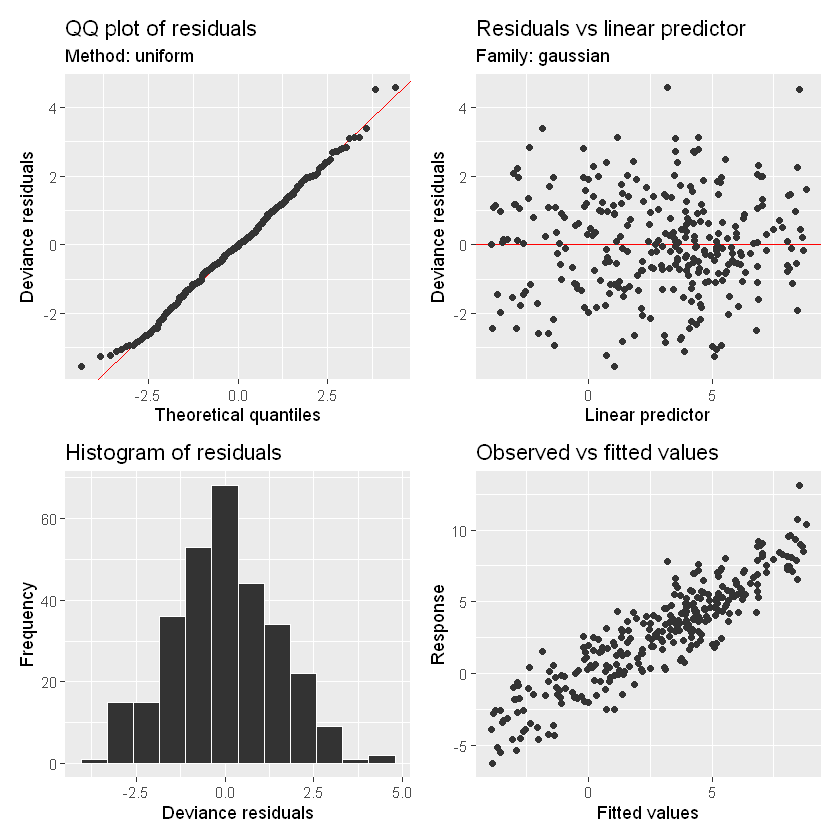

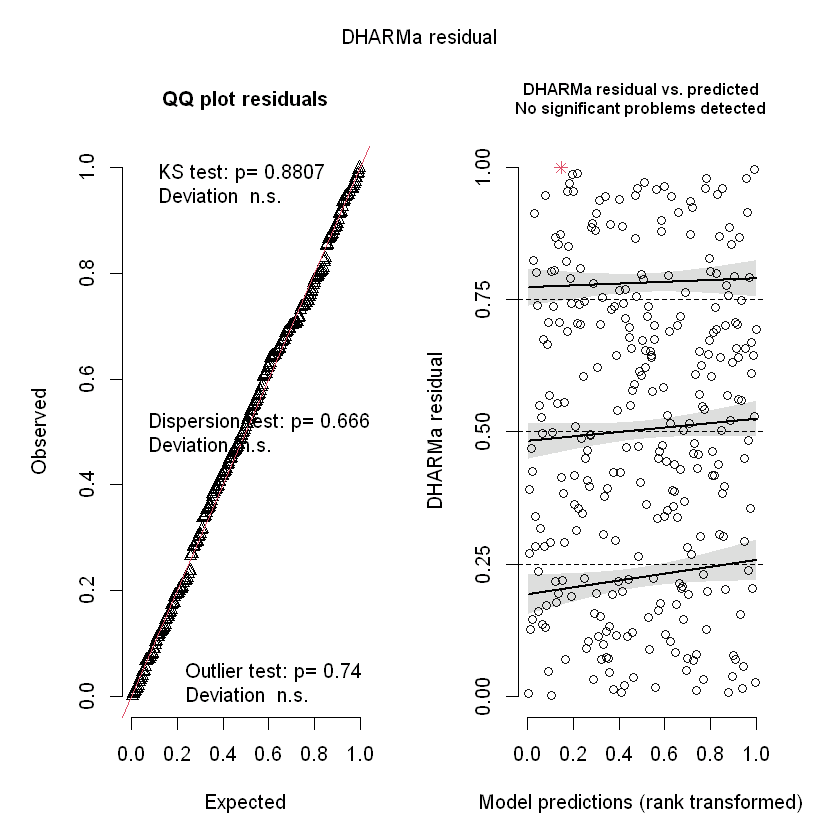


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 0.93158, p-value = 0.666
alternative hypothesis: two.sided


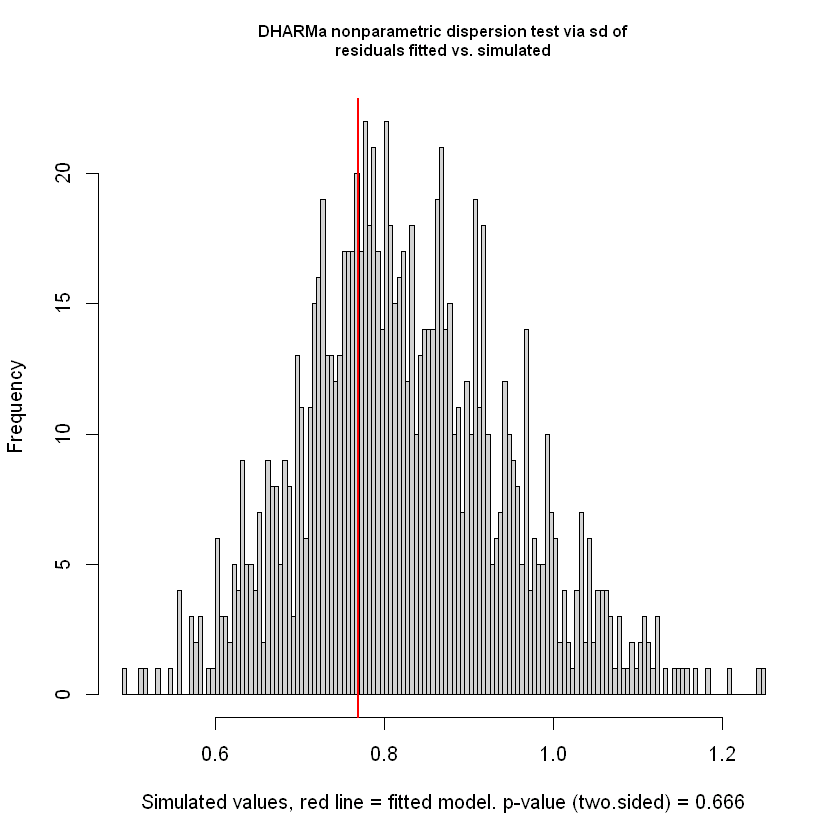

In [9]:
check_gam <- function(model, data, family = "gaussian") {
  cat("=== 1. BASIS DIMENSION CHECK ===\n")
  print(mgcv::k.check(model))

  cat("\n=== 2. CONCURVITY ===\n")
  print(mgcv::concurvity(model, full = TRUE))

  cat("\n=== 3. MODEL FIT SUMMARY ===\n")
  s <- summary(model)
  cat(sprintf("R-sq (adj) = %.3f | Deviance explained = %.1f%% | AIC = %.1f\n",
              s$r.sq, s$dev.expl * 100, AIC(model)))

  cat("\n=== 4. RESIDUAL DIAGNOSTICS ===\n")
  if (family == "gaussian") {
    gratia::appraise(model)
  } else {
    cat("Non-Gaussian: using DHARMa simulation residuals\n")
    sim <- DHARMa::simulateResiduals(model, n = 1000)
    plot(sim)
    DHARMa::testDispersion(sim)
  }
}

# ── Run on Gaussian GAM ───────────────────────────────────────────────────────
check_gam(gam_gauss, gauss_data, family = "gaussian")

# ── Run on NB GAM ─────────────────────────────────────────────────────────────
check_gam(gam_nb, nb_data, family = "nb")

---

## Common Pitfalls

**1. Skipping the k-check**  
An under-specified k forces the smooth to be too simple, missing real non-linearity. `k.check()` takes seconds and should be run after every GAM fit.

**2. Over-interpreting `gam.check()` p-values for non-Gaussian models**  
The residual tests in `gam.check()` assume approximately normal residuals. For binomial, Poisson, or NB GAMs they are unreliable. Use DHARMa instead.

**3. Ignoring high concurvity**  
High concurvity does not bias fixed effect estimates the way multicollinearity does, but it inflates uncertainty and makes individual smooth terms difficult to interpret. Consider removing one of the correlated predictors or combining them.

**4. Treating deviance explained like R²**  
For non-Gaussian families, deviance explained is not directly comparable to R². It depends on the null deviance of that family. Compare models within the same family, not across families.

**5. Not checking residuals against individual predictors**  
The global `appraise()` plot can look fine while a specific predictor has systematic residual structure. Always check residuals against each predictor separately.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*